In [1]:
from ontolearn.owl_neural_reasoner import TripleStoreNeuralReasoner

import time
from typing import Tuple, Set
import pandas as pd
from owlapy import owl_expression_to_dl
from itertools import chain
from argparse import ArgumentParser
import os
from tqdm import tqdm
import random
import itertools
import ast
from owlready2 import get_ontology
# Set pandas options to ensure full output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'left')
pd.set_option('display.expand_frame_repr', False)




def get_score(clifford_embedding, individuals, classes):
    path = f"/home/iroberts/projects/UPB_UBI/KGs_Family_family-benchmark_rich_background_owl_{clifford_embedding}"

    neural_owl_reasoner = TripleStoreNeuralReasoner(path_neural_embedding=path,gamma=0.1)
    score = neural_owl_reasoner.model.predict(h=individuals, 
                                              r="http://www.w3.org/1999/02/22-rdf-syntax-ns#type", 
                                              t=classes,logits=False)

    return score





In [2]:
# Step 1: Load CSV file
def load_csv(file_path):
    """Load a CSV file into a DataFrame."""
    return pd.read_csv(file_path)

def get_entity_df(pqr, label_na=-1, entity_filter=False):
    # File paths
    base_path = f"./KGs_Family_family-benchmark_rich_background_owl_{pqr}"
    entities_file = f"{base_path}/DeCaL_entity_embeddings.csv"
    entity_map_file = f"{base_path}/entity_to_idx.p"

    # Load entity embeddings and map
    entities_df = load_csv(entities_file)  # First column is URI
    return entities_df


In [67]:
from dicee.static_funcs import load_model



# This function will take embeddings and map them to a score for a class
# now I need to find the right
def score(h,r,t,model):

    x = torch.hstack((h,r,t))
    
    return torch.sigmoid(model(x))


kge_path = "/home/iroberts/projects/UPB_UBI/KGs_Family_family-benchmark_rich_background_owl_0_0_0"
model = load_model(path_of_experiment_folder=kge_path)

score()
    

In [3]:
import pandas as pd
import re

def process_family_df(df):
    # Regex patterns
    # Corrected regex patterns
    individual_pattern = r'^http://www\.benchmark\.org/family#F\d+.*$'   # Starts with F + digits
    class_pattern = r'^http://www\.benchmark\.org/family#(?!F\d).*'      # Does NOT start with F + digits
    
    
    # Lists to store URIs
    individual_uris = []
    class_uris = []
    
    # Iterate over URIs in the first column
    for uri in df.iloc[:, 0]:
        if re.match(individual_pattern, uri):
            individual_uris.append(uri)
        elif re.match(class_pattern, uri):
            class_uris.append(uri)
        # else: ignore other URIs
    
    # Filter DataFrame to include only individuals and drop the URI column for embeddings
    # embeddings_df = df[df.iloc[:, 0].isin(individual_uris)].reset_index(drop=True)
    # embeddings_only = embeddings_df.iloc[:, 1:]
    
    return individual_uris, class_uris

inds , classes = process_family_df(get_entity_df("0_0_0"))


In [18]:
classes = [#"http://www.benchmark.org/family#Brother",
"http://www.benchmark.org/family#Male",
# "http://www.benchmark.org/family#PersonWithASibling",
# "http://www.benchmark.org/family#Child",
# "http://www.benchmark.org/family#Person",
# "http://www.benchmark.org/family#Daughter",
"http://www.benchmark.org/family#Female",
"http://www.benchmark.org/family#Father",
# "http://www.benchmark.org/family#Parent",
# "http://www.benchmark.org/family#Grandchild",
# "http://www.benchmark.org/family#Granddaughter",
# "http://www.benchmark.org/family#Grandfather",
# "http://www.benchmark.org/family#Grandparent",
# "http://www.benchmark.org/family#Grandmother",
# "http://www.benchmark.org/family#Grandson",
"http://www.benchmark.org/family#Mother",
# "http://www.benchmark.org/family#Sister",
# "http://www.benchmark.org/family#Son",
]


In [19]:
import pandas as pd
pqrs = [ "0_0_0", "0_0_1", "0_1_0", "0_1_1", "1_0_0", "1_0_1", "1_1_0", "1_1_1"]
            

pqr_dict = {}

for pqr in pqrs:
    individuals, _ = process_family_df(get_entity_df(pqr))
    if not individuals or not classes:
        continue  # Skip if empty
    
    # Initialize DataFrame with individuals as rows and classes as columns
    score_matrix = pd.DataFrame(index=individuals, columns=classes)
    
    for ind in individuals:
        for cl in classes:
            score = get_score(clifford_embedding=pqr, individuals=ind, classes=cl).numpy()
            score_matrix.loc[ind, cl] = score
    
    pqr_dict[pqr] = score_matrix
    

/home/iroberts/miniconda3/envs/concepts_pb_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/iroberts/miniconda3/envs/concepts_pb_bi/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


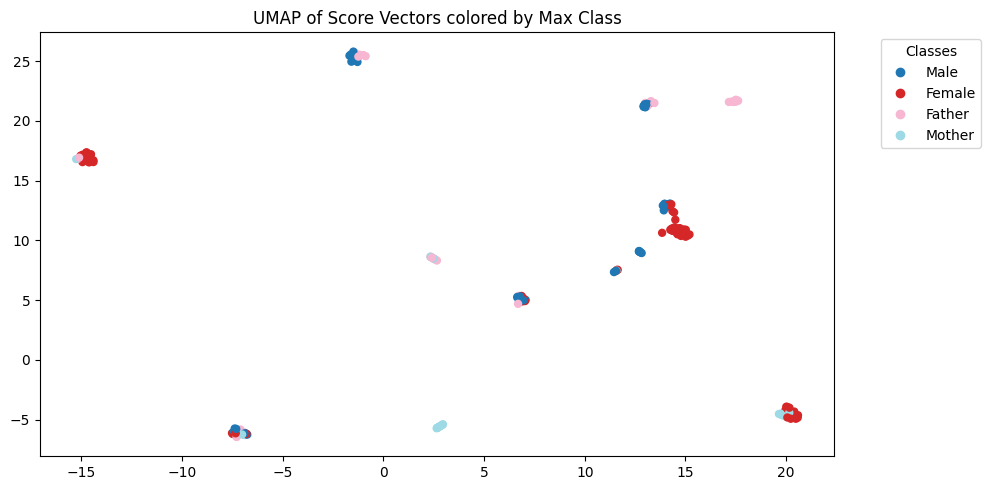

In [57]:
import umap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
pqrs = [ "0_0_0", "0_0_1", "0_1_0", "0_1_1", "1_0_0", "1_0_1", "1_1_0", "1_1_1"]

p_q_r = pqrs[6]

# Drop helper columns if already added
embedding = umap.UMAP(random_state=0).fit_transform(pqr_dict[p_q_r].iloc[:, :].to_numpy())


plt.figure(figsize=(10,5))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], 
                      c=np.argmax(pqr_dict[p_q_r].iloc[:, :].to_numpy(),axis=1), 
                      s=25, cmap='tab20')


# Add legend using unique classes and color handles from scatter
handles, labels = scatter.legend_elements()
unique_classes = np.unique(np.argmax(pqr_dict[p_q_r].iloc[:, :].to_numpy(),axis=1))

legend_labels = [classes[cls].split('#')[-1] for cls in unique_classes]
plt.legend(handles, legend_labels, title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("UMAP of Score Vectors colored by Max Class")
plt.tight_layout()
plt.show()


In [42]:
score_matrix.shape

(202, 4)

/home/iroberts/miniconda3/envs/concepts_pb_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/iroberts/miniconda3/envs/concepts_pb_bi/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


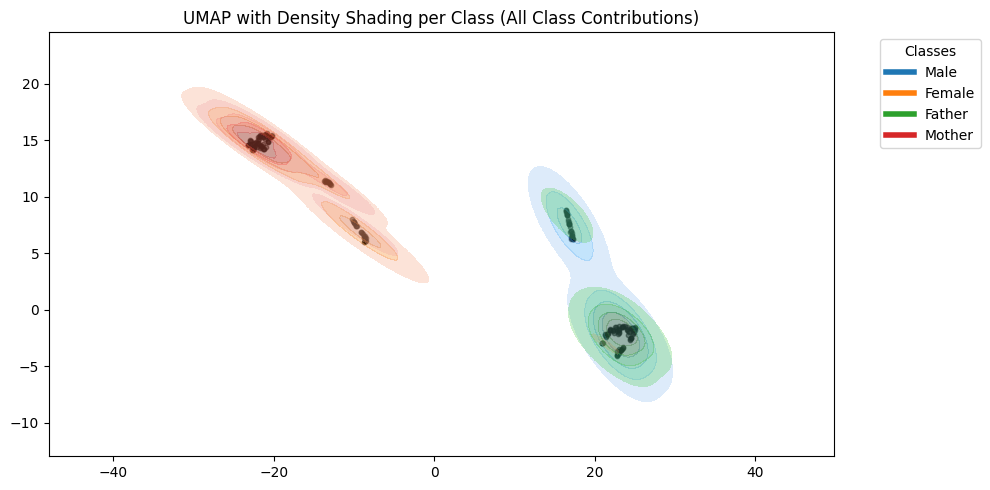

In [60]:
import umap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

p_q_r = pqrs[1]


score_matrix = pqr_dict[p_q_r].iloc[:, :].to_numpy()
embedding = umap.UMAP(random_state=0).fit_transform(score_matrix)

plt.figure(figsize=(10, 5))

# Plot all points in light grey
plt.scatter(embedding[:, 0], embedding[:, 1], color='black', s=10, alpha=0.5)

# Get colormap for classes
cmap = plt.get_cmap('tab10')
num_classes = score_matrix.shape[1]

for cls_idx in range(num_classes):
    class_points = embedding
    class_scores = score_matrix[:, cls_idx]
    
    # Only plot KDE if class has any contribution
    if np.any(class_scores > .5):
        sns.kdeplot(
            x=class_points[:, 0],
            y=class_points[:, 1],
            weights=class_scores,   # Weight density by class score
            fill=True,
            alpha=0.3,
            levels=5,
            color=cmap(cls_idx)
        )

# Legend for classes
legend_labels = [classes[cls_idx].split('#')[-1] for cls_idx in range(num_classes)]
handles = [plt.Line2D([0], [0], color=cmap(cls_idx), lw=4) for cls_idx in range(num_classes)]
plt.legend(handles, legend_labels, title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("UMAP with Density Shading per Class (All Class Contributions)")
plt.tight_layout()
plt.show()





In [ ]:

for i,label in enumerate(inds):
    short_label = label.replace("http://www.benchmark.org/family#", "")[:30]
    print(short_label)
    plt.annotate(short_label, (embedding[:, 0][i], embedding[:, 1][i]), fontsize=7, alpha=0.8)
    
